In [75]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math
from typing import List
from tqdm import tqdm

In [93]:
class NaiveMLP:
  def __init__(self, npl: List[int]):
    self.d = list(npl)
    self.L = len(npl) - 1

    self.W = []
    for l in range(0, self.L + 1):
      self.W.append([])
      if l == 0:
        continue
      for i in range(0, self.d[l - 1] + 1):
        self.W[l].append([])
        for j in range(0, self.d[l] + 1):
          if j == 0:
            self.W[l][i].append(0.0)
          else:
            self.W[l][i].append(random.random() * 2.0 - 1.0)

    self.X = []
    self.deltas = []
    for l in range(0, self.L + 1):
      self.X.append([])
      self.deltas.append([])
      for j in range(0, self.d[l] + 1):
        self.deltas[l].append(0.0)
        self.X[l].append(1.0 if j == 0 else 0.0)

  def _propagate(self, inputs: List[float], is_classification: bool):
    for j in range(1, self.d[0] + 1):
      self.X[0][j] = inputs[j - 1]

    for l in range(1, self.L + 1):
      for j in range(1, self.d[l] + 1):
        total = 0.0
        for i in range(0, self.d[l - 1] + 1):
          total += self.W[l][i][j] * self.X[l - 1][i]
        if is_classification or l < self.L:
          total = math.tanh(total)
        self.X[l][j] = total

  def predict(self, inputs: List[float], is_classification: bool):
    self._propagate(inputs, is_classification)
    return self.X[self.L][1:]

  def train(self, dataset_inputs: List[List[float]], dataset_expected_outputs: List[List[float]],
            training_steps: int,
            learning_rate: float,
            is_classification: bool
            ):
    for _ in tqdm(range(training_steps)):
      k = random.randint(0, len(dataset_inputs) - 1)
      inputs_k = dataset_inputs[k]
      y_k = dataset_expected_outputs[k]

      self._propagate(inputs_k, is_classification)
      for j in range(1, self.d[self.L] + 1):
        self.deltas[self.L][j] = self.X[self.L][j] - y_k[j - 1]
        if is_classification:
          self.deltas[self.L][j] *= (1.0 - self.X[self.L][j] ** 2)

      for l in reversed(range(2, self.L + 1)):
        for i in range(1, self.d[l - 1] + 1):
          total = 0.0
          for j in range(1, self.d[l] + 1):
            total += self.W[l][i][j] * self.deltas[l][j]

          total *= (1.0 - self.X[l - 1][i] ** 2)
          self.deltas[l - 1][i] = total

      for l in range(1, self.L + 1):
        for i in range(0, self.d[l - 1] + 1):
          for j in range(1, self.d[l] + 1):
            self.W[l][i][j] -= learning_rate * self.X[l - 1][i] * self.deltas[l][j]



# XOR dataset

In [94]:
dataset_inputs = np.array([
    [1.0, 1.0],
    [1.0, 0.0],
    [0.0, 1.0],
    [0.0, 0.0],
])

dataset_expected_outputs = np.array([
    [-1.0],
    [1.0],
    [1.0],
    [-1.0],
])

In [95]:
colors = ['blue' if y == 1.0 else 'red' for y in dataset_expected_outputs]

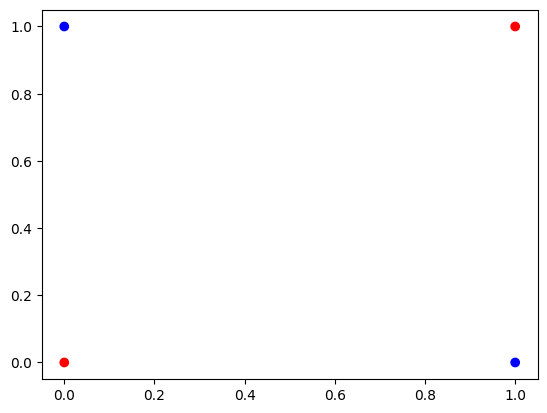

In [96]:
plt.scatter(dataset_inputs[:, 0], dataset_inputs[:, 1], c=colors)
plt.show()

In [121]:
model = NaiveMLP([2, 2, 1])

In [122]:
points_to_predict = []
predicted_colors = []
for row in range(100):
  for col in range(100):
    point_to_predict = [row / 100.0, col / 100.0]
    points_to_predict.append(point_to_predict)
    predicted_colors.append(
        'lightblue' if model.predict(point_to_predict, True)[0] >= 0 else 'pink')
points_to_predict = np.array(points_to_predict)

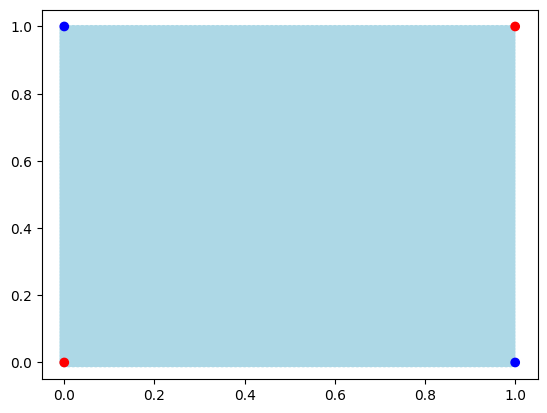

In [123]:
plt.scatter(points_to_predict[:, 0], points_to_predict[:, 1], c=predicted_colors)
plt.scatter(dataset_inputs[:, 0], dataset_inputs[:, 1], c=colors)
plt.show()

In [124]:
model.train(dataset_inputs, dataset_expected_outputs, 100_000, 0.01, True)

100%|██████████| 100000/100000 [00:02<00:00, 40233.83it/s]


In [125]:
points_to_predict = []
predicted_colors = []
for row in range(100):
  for col in range(100):
    point_to_predict = [row / 100.0, col / 100.0]
    points_to_predict.append(point_to_predict)
    predicted_colors.append(
        'lightblue' if model.predict(point_to_predict, True)[0] >= 0 else 'pink')
points_to_predict = np.array(points_to_predict)

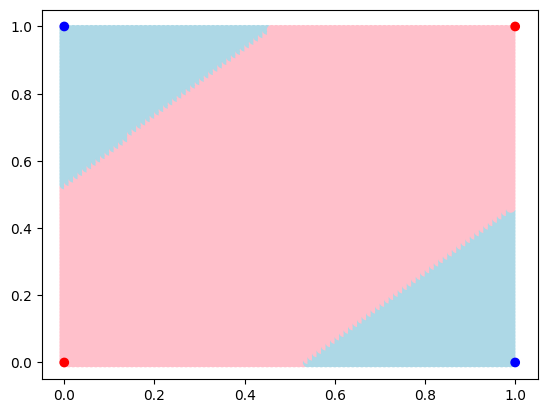

In [126]:
plt.scatter(points_to_predict[:, 0], points_to_predict[:, 1], c=predicted_colors)
plt.scatter(dataset_inputs[:, 0], dataset_inputs[:, 1], c=colors)
plt.show()

# x² Dataset

In [162]:
dataset_inputs = np.array([[i / 100.0] for i in range(100)])
dataset_expected_outputs = np.array([[(i / 100.0 - 1) ** 2] for i in range(100)])

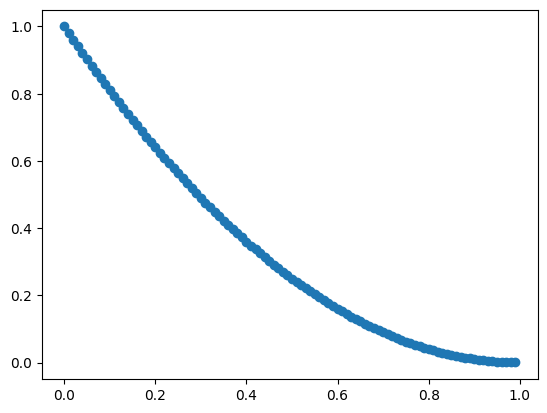

In [163]:
plt.scatter(dataset_inputs[:, 0], dataset_expected_outputs[:, 0])
plt.show()

In [164]:
model = NaiveMLP([1, 8, 8, 1])

In [165]:
model.train(dataset_inputs, dataset_expected_outputs, 100_000, 0.01, False)

100%|██████████| 100000/100000 [00:10<00:00, 9319.55it/s]


In [166]:
predicted_outputs = np.array([model.predict(inputs, False) for inputs in dataset_inputs])

In [167]:
predicted_outputs

array([[ 9.91250890e-01],
       [ 9.73098089e-01],
       [ 9.54990593e-01],
       [ 9.36933684e-01],
       [ 9.18932755e-01],
       [ 9.00993297e-01],
       [ 8.83120895e-01],
       [ 8.65321221e-01],
       [ 8.47600026e-01],
       [ 8.29963131e-01],
       [ 8.12416414e-01],
       [ 7.94965806e-01],
       [ 7.77617276e-01],
       [ 7.60376820e-01],
       [ 7.43250450e-01],
       [ 7.26244181e-01],
       [ 7.09364018e-01],
       [ 6.92615941e-01],
       [ 6.76005896e-01],
       [ 6.59539775e-01],
       [ 6.43223407e-01],
       [ 6.27062540e-01],
       [ 6.11062829e-01],
       [ 5.95229821e-01],
       [ 5.79568940e-01],
       [ 5.64085473e-01],
       [ 5.48784560e-01],
       [ 5.33671174e-01],
       [ 5.18750116e-01],
       [ 5.04025994e-01],
       [ 4.89503218e-01],
       [ 4.75185988e-01],
       [ 4.61078279e-01],
       [ 4.47183835e-01],
       [ 4.33506162e-01],
       [ 4.20048513e-01],
       [ 4.06813890e-01],
       [ 3.93805030e-01],
       [ 3.8

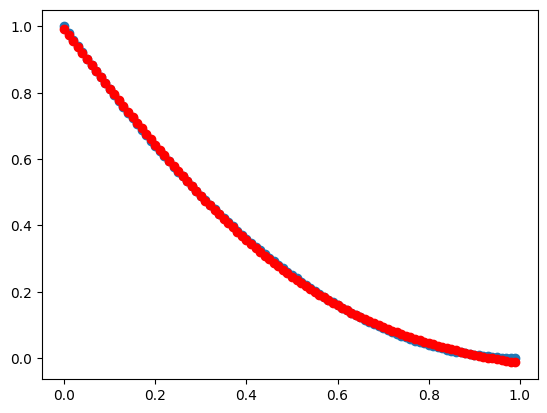

In [168]:
plt.scatter(dataset_inputs[:, 0], dataset_expected_outputs[:, 0])
plt.scatter(dataset_inputs[:, 0], predicted_outputs[:, 0], c='red')
plt.show()